In [2]:
import pandas as pd

df = pd.read_csv("../dataset/maternal_health_cleaned.csv")

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


### 1.4 stratified train/test split


In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("RiskLevel", axis=1)
y = df["RiskLevel"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Verify stratification actually worked
print("Original:")
print(y.value_counts(normalize=True))

print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Original:
RiskLevel
low risk     0.516630
high risk    0.248337
mid risk     0.235033
Name: proportion, dtype: float64
Training class distribution:
RiskLevel
low risk     0.516667
high risk    0.247222
mid risk     0.236111
Name: proportion, dtype: float64

Test class distribution:
RiskLevel
low risk     0.516484
high risk    0.252747
mid risk     0.230769
Name: proportion, dtype: float64


stratify=y tells Python when you split the dataset, try to keep the same proportion of low-, mid-, and high-risk cases in the training and test sets.

## Model Development

### 2.1 Logistic Regeression

##### 2.1 Logistic Regression Implementation
1. Scale training/test data
2. Apply SMOTE to training data only
3. Create baseline Logistic Regression
4. Hyperparameter tuning
5. Train best Logistic Regression
6. Generate final y_pred_lr

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. Build pipeline: scaling -> SMOTE -> Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("lr", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

# 2. Hyperparameters to test
param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10, 100]
}

# 3. Hyperparameter tuning using 5-fold cross-validation
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# 4. Train on the training set
grid_search_lr.fit(X_train, y_train)

# 5. Get the best trained model
best_lr_model = grid_search_lr.best_estimator_

print("Best parameters:", grid_search_lr.best_params_)
print("Best CV Macro-F1:", grid_search_lr.best_score_)

# 6. Predict on the untouched test set
y_pred_lr = best_lr_model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred_lr[:10])

Best parameters: {'lr__C': 0.1}
Best CV Macro-F1: 0.5526051469049547

First 10 predictions:
['low risk' 'low risk' 'mid risk' 'low risk' 'mid risk' 'mid risk'
 'high risk' 'mid risk' 'low risk' 'low risk']


### 2.2 Random Forest

##### 2.2 Random Forest Implementation
1. Apply SMOTE to training data only
2. Create baseline Random Forest
3. Hyperparameter tuning 
4. Train/use best Random Forest
5. Generate final y_pred_rf

In [ ]:
## NO PIPELINE (DEMO ONLY NOT USED)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# 1. Apply SMOTE to the training data only
smote_rf = SMOTE(random_state=42)

X_train_smote_rf, y_train_smote_rf = smote_rf.fit_resample(
    X_train,
    y_train
)


# Check class distribution before and after SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote_rf.value_counts())


# 2. Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42
)


# 3. Define hyperparameters to test
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


# 4. Hyperparameter tuning
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search_rf.fit(
    X_train_smote_rf,
    y_train_smote_rf
)


# 5. Get the best model
best_rf_model = grid_search_rf.best_estimator_

print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validation macro-F1:", grid_search_rf.best_score_)


# 6. Generate predictions for Section 3 evaluation
y_pred_rf = best_rf_model.predict(X_test)

Before SMOTE:
RiskLevel
low risk     186
high risk     89
mid risk      85
Name: count, dtype: int64

After SMOTE:
RiskLevel
low risk     186
mid risk     186
high risk    186
Name: count, dtype: int64
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation macro-F1: 0.7517281118378223


##### SMOTE before GridSearchCV

In this approach, SMOTE is applied to the entire training set before cross-validation. The balanced training data is then passed into `GridSearchCV` for hyperparameter tuning.

This approach works, but it is less leakage-safe because synthetic samples are created before the cross-validation folds are formed. Related synthetic observations may therefore appear across different folds, which can make validation performance slightly more optimistic.

In [11]:
## WITH PIPELINE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Build pipeline
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

# 2. Hyperparameters to test
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

# 3. Grid search
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# 4. Fit on ORIGINAL training data
grid_search_rf.fit(X_train, y_train)

# 5. Best pipeline
best_rf_model = grid_search_rf.best_estimator_

print("Best parameters:", grid_search_rf.best_params_)
print("Best CV macro-F1:", grid_search_rf.best_score_)

# 6. Final predictions on untouched test data
y_pred_rf = best_rf_model.predict(X_test)

Best parameters: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV macro-F1: 0.6261280471290844


##### SMOTE inside a Pipeline

In this approach, SMOTE and Random Forest are combined inside an `imblearn` Pipeline. During `GridSearchCV`, SMOTE is applied separately within each training fold, while the validation fold remains untouched.

This is more leakage-safe because synthetic samples are generated only from the data available in each training fold. Therefore, this pipeline version is preferred for the final model development and hyperparameter tuning.

**Main difference:** The first approach applies SMOTE before cross-validation, while the pipeline approach applies SMOTE inside each cross-validation training fold. The pipeline approach therefore provides a more reliable estimate of model performance.

### Random Forest: SMOTE Before GridSearchCV vs. SMOTE Inside Pipeline

Two approaches were tested for handling class imbalance with SMOTE.

**Approach 1) SMOTE before GridSearchCV:**  
SMOTE was applied to the entire training set before cross-validation. This produced a higher cross-validation Macro-F1 score (~0.752). However, because synthetic samples were generated before the cross-validation folds were created, related synthetic observations may appear across training and validation folds. This can cause data leakage and produce an overly optimistic estimate of model performance.

**Approach 2) SMOTE inside an imblearn Pipeline:**  
SMOTE was included inside the pipeline with Random Forest. During GridSearchCV, SMOTE is therefore applied only to the training portion of each cross-validation fold, while the validation portion remains untouched. This produced a lower Macro-F1 score (~0.626), but provides a more reliable and leakage-safe estimate of model performance.

**Decision:**  
The pipeline approach will be used for final Random Forest model development and hyperparameter tuning because it prevents information leakage during cross-validation. The higher score from applying SMOTE before GridSearchCV should not be interpreted as evidence of better model performance.

## Model Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

#### 3.1 Accuracy, Precision, Recall, and Macro-F1

In [12]:
# Store model predictions
predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
}

results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1
    })


results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.604396,0.588158,0.538963,0.555245
1,Random Forest,0.692308,0.658991,0.592940,0.594314


#### 3.2 Confusion Matrices

In [13]:
# Confusion matrices
for model_name, y_pred in predictions.items():

    print(f"\n{model_name}")
    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["low risk", "mid risk", "high risk"]
    )

    print(cm)


# Classification reports
for model_name, y_pred in predictions.items():

    print(f"\n===== {model_name} =====")

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


Logistic Regression
Confusion Matrix:
[[36 11  0]
 [12  6  3]
 [ 5  5 13]]

Random Forest
Confusion Matrix:
[[44  1  2]
 [15  4  2]
 [ 5  3 15]]

===== Logistic Regression =====
              precision    recall  f1-score   support

   high risk       0.81      0.57      0.67        23
    low risk       0.68      0.77      0.72        47
    mid risk       0.27      0.29      0.28        21

    accuracy                           0.60        91
   macro avg       0.59      0.54      0.56        91
weighted avg       0.62      0.60      0.60        91


===== Random Forest =====
              precision    recall  f1-score   support

   high risk       0.79      0.65      0.71        23
    low risk       0.69      0.94      0.79        47
    mid risk       0.50      0.19      0.28        21

    accuracy                           0.69        91
   macro avg       0.66      0.59      0.59        91
weighted avg       0.67      0.69      0.65        91



#### 3.3 High-Risk Recall

In [14]:
high_risk_results = []

for model_name, y_pred in predictions.items():

    high_risk_recall = recall_score(
        y_test,
        y_pred,
        labels=["high risk"],
        average=None,
        zero_division=0
    )[0]

    high_risk_results.append({
        "Model": model_name,
        "High-Risk Recall": high_risk_recall
    })


high_risk_df = pd.DataFrame(high_risk_results)

high_risk_df

,Model,High-Risk Recall
0,Logistic Regression,0.565217
1,Random Forest,0.652174


In [15]:
high_risk_fnr_results = []

for model_name, y_pred in predictions.items():

    actual_high = (y_test == "high risk")
    predicted_high = (y_pred == "high risk")

    # High-risk true positives
    TP = ((actual_high) & (predicted_high)).sum()

    # High-risk false negatives:
    # actually high risk but predicted as another class
    FN = ((actual_high) & (~predicted_high)).sum()

    false_negative_rate = FN / (TP + FN)

    high_risk_fnr_results.append({
        "Model": model_name,
        "High-Risk True Positives": TP,
        "High-Risk False Negatives": FN,
        "High-Risk False Negative Rate": false_negative_rate
    })


high_risk_fnr_df = pd.DataFrame(high_risk_fnr_results)

high_risk_fnr_df

,Model,High-Risk True Positives,High-Risk False Negatives,High-Risk False Negative Rate
0,Logistic Regression,13,10,0.434783
1,Random Forest,15,8,0.347826


#### 3.4 Final Model Comparison

In [16]:
final_results_df = results_df.merge(
    high_risk_df,
    on="Model"
)

final_results_df = final_results_df.merge(
    high_risk_fnr_df[
        [
            "Model",
            "High-Risk False Negatives",
            "High-Risk False Negative Rate"
        ]
    ],
    on="Model"
)

final_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,High-Risk Recall,High-Risk False Negatives,High-Risk False Negative Rate
0,Logistic Regression,0.604396,0.588158,0.538963,0.555245,0.565217,10,0.434783
1,Random Forest,0.692308,0.658991,0.592940,0.594314,0.652174,8,0.347826


#### ^ Model Evaluation

All models are evaluated on the same untouched test set to ensure a fair
comparison. Overall performance is assessed using accuracy, macro precision,
macro recall, and macro F1-score.

Because failure to identify a high-risk pregnancy is particularly important
for this application, high-risk recall and the high-risk false-negative rate
are also evaluated separately. A desirable model should achieve strong
overall classification performance while maximizing high-risk recall and
minimizing high-risk false negatives.

### **3.5 Model Evaluation Summary and Visualizations**

The models are compared using overall classification performance and their ability to correctly identify high-risk cases.

Because missing a high-risk case is particularly important in this application, high-risk recall and false-negative rate (FNR) are highlighted alongside the overall metrics.

Higher accuracy, Macro-F1, and high-risk recall are desirable, while a lower high-risk false-negative rate is preferred.

#### 1. Overall model performance
visual comparison of Accuracy, Macro-F1, and High-Risk Recall.

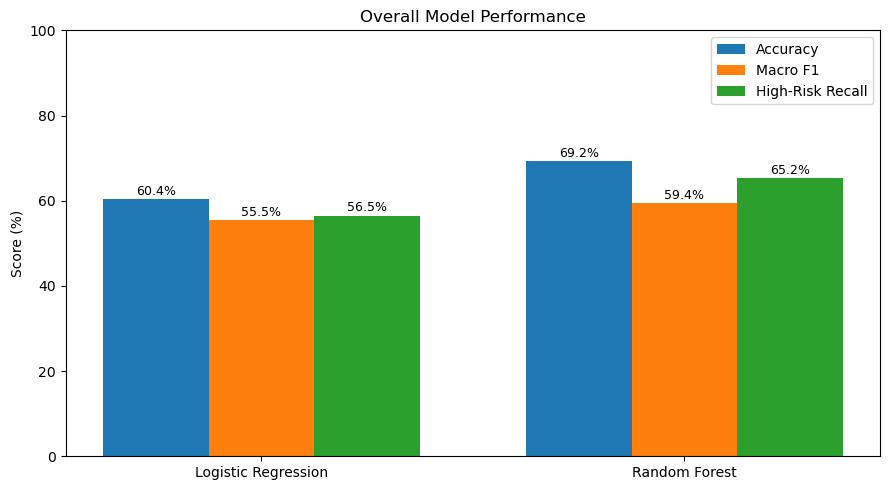

In [17]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Macro F1", "High-Risk Recall"]
models = final_results_df["Model"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(metrics):
    values = final_results_df[metric] * 100
    bars = plt.bar(x + i * width, values, width, label=metric)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center",
            fontsize=9
        )

plt.xticks(x + width, models)
plt.ylabel("Score (%)")
plt.title("Overall Model Performance")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

#### 2. High-risk detection
Visualizes how many high-risk cases were caught vs missed.

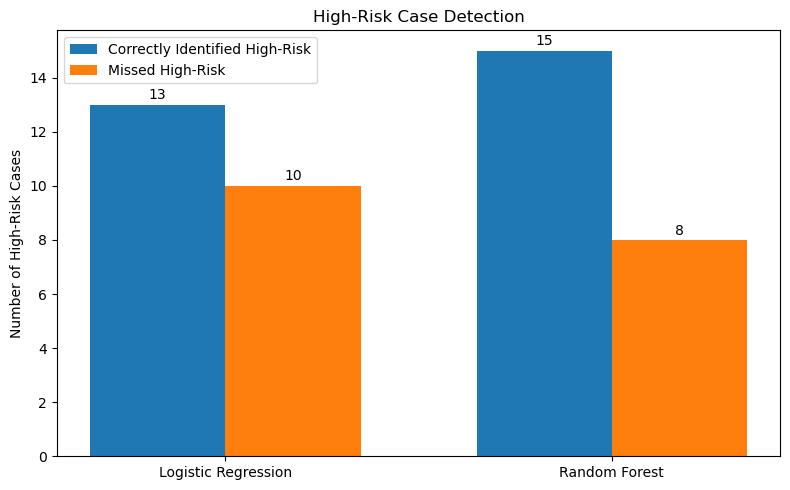

In [18]:
models = high_risk_fnr_df["Model"]
true_positives = high_risk_fnr_df["High-Risk True Positives"]
false_negatives = high_risk_fnr_df["High-Risk False Negatives"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    true_positives,
    width,
    label="Correctly Identified High-Risk"
)

bars2 = plt.bar(
    x + width/2,
    false_negatives,
    width,
    label="Missed High-Risk"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            str(int(bar.get_height())),
            ha="center"
        )

plt.xticks(x, models)
plt.ylabel("Number of High-Risk Cases")
plt.title("High-Risk Case Detection")
plt.legend()
plt.tight_layout()
plt.show()

#### 3. High-risk recall vs false-negative rate


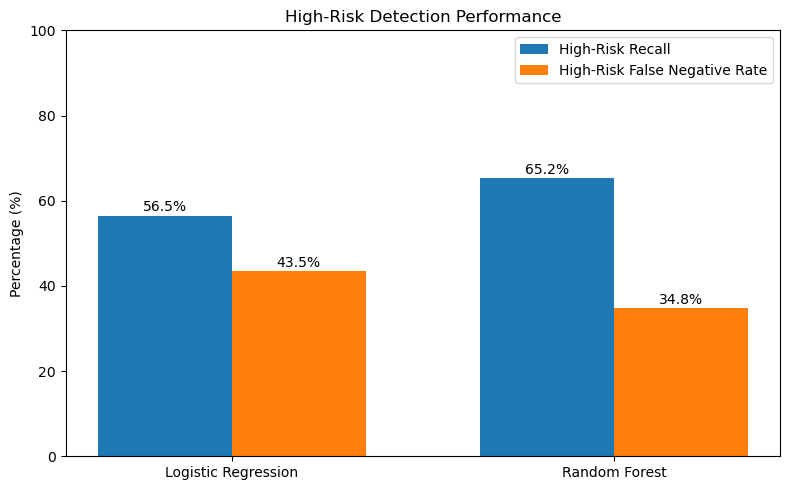

In [19]:
models = final_results_df["Model"]

high_risk_recall = final_results_df["High-Risk Recall"] * 100
high_risk_fnr = final_results_df["High-Risk False Negative Rate"] * 100

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    high_risk_recall,
    width,
    label="High-Risk Recall"
)

bars2 = plt.bar(
    x + width/2,
    high_risk_fnr,
    width,
    label="High-Risk False Negative Rate"
)

for bars in [bars1, bars2]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{bar.get_height():.1f}%",
            ha="center"
        )

plt.xticks(x, models)
plt.ylabel("Percentage (%)")
plt.title("High-Risk Detection Performance")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()